In [1]:
# import modules
import numpy as np
import random
import math
import pandas as pd
# import scipy.stats as stats
# import seaborn as sns
import sys
import matplotlib.pyplot as plt
from tqdm import tqdm
from time import time
import tensorflow as tf
import tensorflow_probability as tfp
tfd = tfp.distributions
tfb = tfp.bijectors

np.set_printoptions(suppress=True)

In [2]:
# First generate some synthetic data
# Generate random covariate fields
# We use 2 simulated covariates

L = 50.0 # size of domain
x = y = np.arange(0,L+1,1)
var=1.0

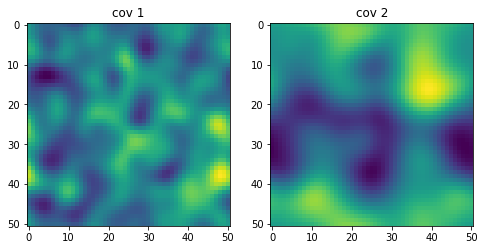

In [3]:
# Make the environment using a correlated periodic Gaussian random field

x = y = np.arange(0,L+1,1)
xx, yy = np.meshgrid(x,y)

positions = np.vstack([xx.ravel(), yy.ravel()]).T

len_scale_1 = 5
period = np.float64(L)
periodic_len = (2**0.5)*len_scale_1*np.pi/period


kernel = tfp.math.psd_kernels.ExpSinSquared(length_scale=periodic_len,period=period)
gp = tfd.GaussianProcess(kernel, positions)

samples = gp.sample()
cov1 = samples.numpy().reshape(51,51)


len_scale_2 = 10
period = np.float64(L)
periodic_len = (2**0.5)*len_scale_2*np.pi/period


kernel = tfp.math.psd_kernels.ExpSinSquared(length_scale=periodic_len,period=period)
gp = tfd.GaussianProcess(kernel, positions)

samples = gp.sample()
cov2 = samples.numpy().reshape(51,51)


fig, ax = plt.subplots(1,2,figsize=(8,6))
ax[0].set_title('cov 1')
ax[0].imshow(cov1)
ax[1].set_title('cov 2')
ax[1].imshow(cov2)
plt.show()

cov_cube = np.stack((cov1,cov2))

In [5]:
# Simulating observation from centred model
 
nbObs=10001 #nbObs Number of observations
beta=np.array([[0.5,-0.8*0]]) # Vector of resource selection coefficients
allr=np.ones(nbObs) # Vector of radii for movement kernel, or standard deviations
cov=cov_cube #Array of covariates (one layer for each covariate)
xy0=[25,25] #Initial location
npts=100 # Number of potential endpoints to sample at each time step
xy1=np.zeros((nbObs,2))
xy1[0] = xy0
x_min = [0., 0.]
x_max = [L, L]
   
# Convert the covariates to tensor 
cov_tensor = tf.transpose(tf.convert_to_tensor(cov_cube,dtype=tf.float32),[2,1,0])
beta_tensor = tf.convert_to_tensor(beta,dtype=tf.float32)
    
C=np.zeros((2))
allrsf=np.zeros(npts)
dt = np.zeros(nbObs)
ID = np.zeros(nbObs)
cid=0
t = 1
for t in tqdm(range(1,nbObs)):
    cdt = np.random.normal(loc=1.0,scale=0.1)
    C[0] = np.random.normal(loc=xy1[t-1,0],scale=allr[t-1]*((0.5*cdt)**0.5))
    C[1] = np.random.normal(loc=xy1[t-1,1],scale=allr[t-1]*((0.5*cdt)**0.5))
        
    grid=np.zeros((npts,2))
    # sample npts points in the circle
    
    grid[:,0]=np.random.normal(loc=C[0], scale=allr[t-1]*((0.5*cdt)**0.5),size=npts)
    grid[:,1]=np.random.normal(loc=C[1], scale=allr[t-1]*((0.5*cdt)**0.5),size=npts)               
    
    # Convert grid to tensor before extracting the values
    zgrid=tf.convert_to_tensor(grid%L,dtype=tf.float32)

    # calculate the covariates at the step end locations using tensorflow probability
    cov_xy_end = tfp.math.batch_interp_regular_nd_grid(zgrid, x_min, x_max, cov_tensor, axis=-3)
            
    # calculate the rsf
    allrsf= np.array(tf.exp(tf.reduce_sum(tf.multiply(cov_xy_end,beta_tensor),axis=-1)))
        
    next_point=random.choices(population=grid,weights=allrsf,k=1)
    
    dt[t-1]=cdt
    xy1[t]=next_point[0] 
        
    ID[t]=cid

100%|██████████| 10000/10000 [03:01<00:00, 55.06it/s]


In [17]:
import matplotlib.ticker as tick
plt.style.use('ggplot') 
plt.style.use('seaborn-paper') 
plt.style.use('seaborn-whitegrid') 

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(24,20))

axs[0, 0].set_aspect('equal')


ax00 = axs[0, 0].contourf(cov1,cmap='viridis',levels=20)
#axs[0,0].set_title('A',loc='left',size=30,pad=100)
axs[0,0].text(-0.1,1,'A', size=30, transform=axs[0, 0].transAxes)
axs[0,0].tick_params( labelleft=False, labelbottom=False) 
cbar = fig.colorbar(ax00, ax=axs[0, 0],format=tick.FormatStrFormatter('%.1f'),fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=20) 
cbar.set_label(label=r'environmental covariate $\beta_0$',size=20)
tick_locator = tick.MaxNLocator(nbins=7)
cbar.locator = tick_locator
cbar.update_ticks()

axs[0, 1].set_aspect('equal')


ax01 = axs[0, 1].contourf(cov2,cmap='viridis',levels=20)
#axs[0,0].set_title('A',loc='left',size=30,pad=100)
axs[0,1].text(-0.1,1,'B', size=30, transform=axs[0, 1].transAxes)
axs[0,1].tick_params( labelleft=False, labelbottom=False) 
cbar = fig.colorbar(ax01, ax=axs[0, 1],format=tick.FormatStrFormatter('%.1f'),fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=20) 
cbar.set_label(label=r'environmental covariate $\beta_1$',size=20)
tick_locator = tick.MaxNLocator(nbins=7)
cbar.locator = tick_locator
cbar.update_ticks()


axs[1, 0].set_aspect('equal')



MN=np.exp(0.5*cov1 + (-0.8*cov2))
UD=np.divide(MN,np.sum(MN))




ax01 = axs[1, 0].contourf(UD,cmap='viridis',levels=20)
#axs[0,0].set_title('A',loc='left',size=30,pad=100)
axs[1,0].text(-0.1,1,'C', size=30, transform=axs[1, 0].transAxes)
axs[1,0].tick_params( labelleft=False, labelbottom=False) 
cbar = fig.colorbar(ax01, ax=axs[1, 0],fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=20) 
cbar.formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.get_offset_text().set_fontsize(20)
cbar.ax.yaxis.set_offset_position('left')                         
cbar.ax.tick_params(labelsize=20) 
cbar.set_label(label=r'theoretical utilisation probability',size=20)
tick_locator = tick.MaxNLocator(nbins=5)
cbar.locator = tick_locator
cbar.update_ticks()

# axs[1,0].plot(xy1[0:10000,0]%50,xy1[0:10000,1]%50,'.',color="black")
axs[1, 1].set_aspect('equal')


(counts, xedges, yedges, ax11) = axs[1, 1].hist2d(xy1[100:,0]%50,xy1[100:,1]%50,bins=50,cmap='viridis',density=True)#.hist2d(xy1[0:10000,:]%50) #UD,cmap='viridis',levels=20)
#axs[0,0].set_title('A',loc='left',size=30,pad=100)
axs[1,1].text(-0.1,1,'D', size=30, transform=axs[1, 1].transAxes)
axs[1,1].tick_params( labelleft=False, labelbottom=False) 
cbar = fig.colorbar(ax11, ax=axs[1, 1],fraction=0.046, pad=0.04)
cbar.formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.get_offset_text().set_fontsize(20)
cbar.ax.yaxis.set_offset_position('left')                         
cbar.ax.tick_params(labelsize=20) 
cbar.set_label(label=r'simulated utilisation',size=20)
tick_locator = tick.MaxNLocator(nbins=5)
cbar.locator = tick_locator
cbar.update_ticks()

plt.subplots_adjust(wspace=0.1, hspace=0.1)


plt.savefig("covariates_and_distributions.png",bbox_inches='tight',dpi=300)
plt.show()

9.62720722778457e-05
1.0
0.0001203706301094548
0.9999999999999998
0.0001926663036042821
0.9999999999999998
0.00026772771810342264


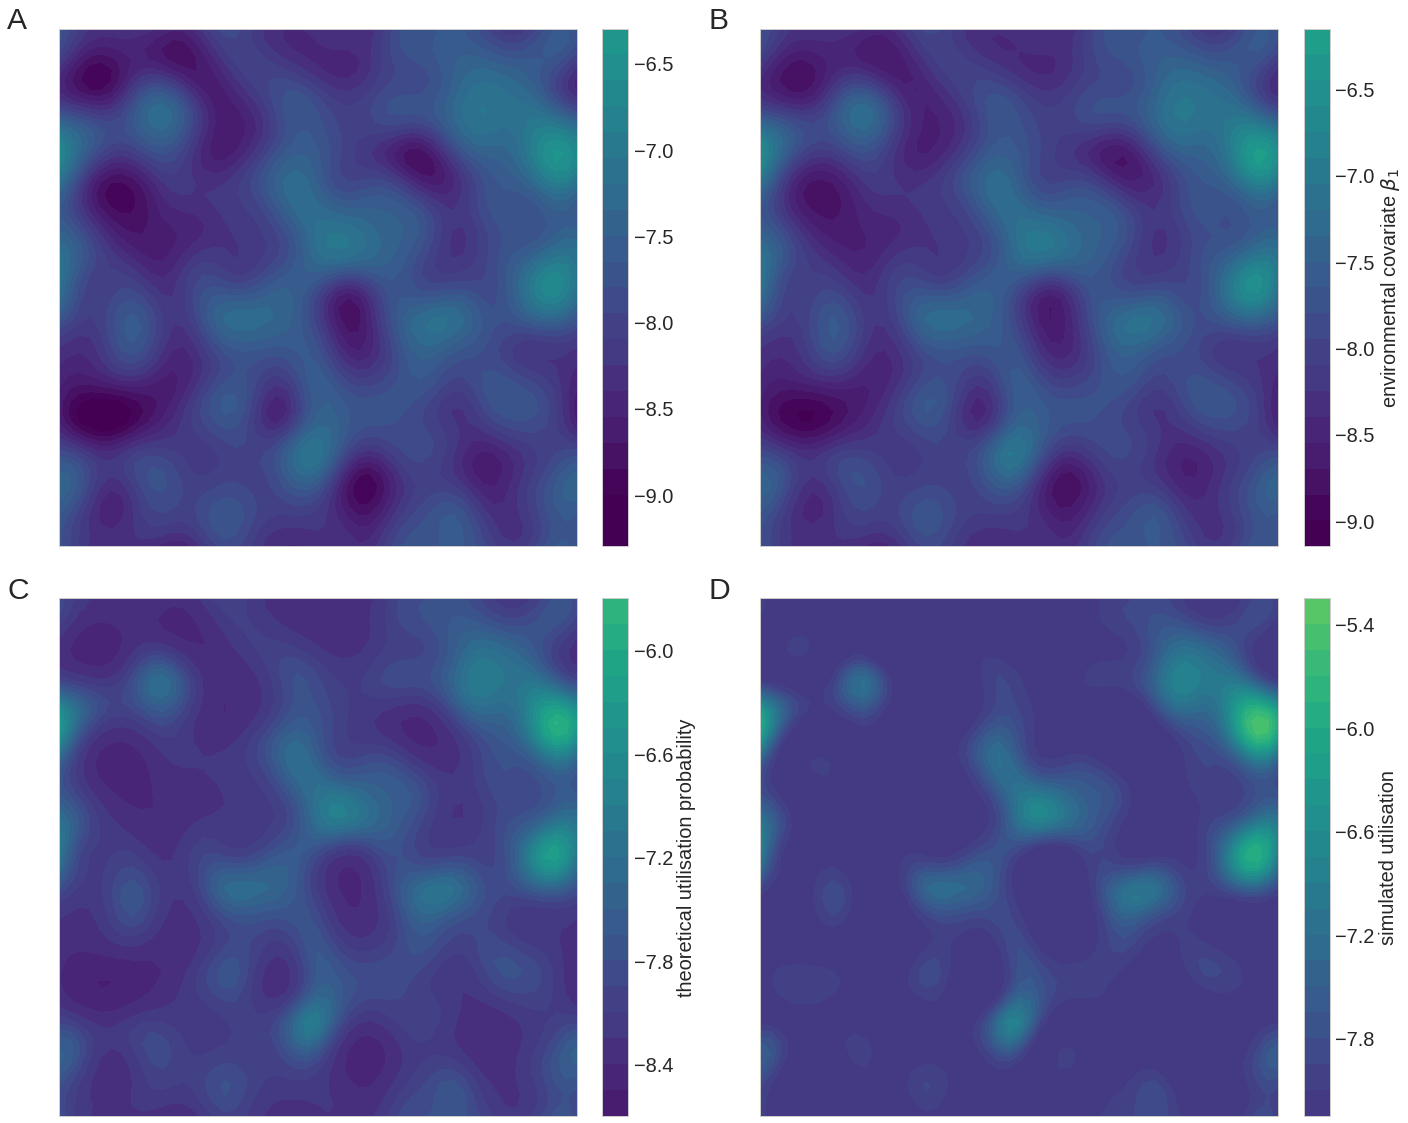

In [101]:
fig, axs = plt.subplots(2, 2, figsize=(24,20))

axs[0, 0].set_aspect('equal')





MN=np.exp(0.5*cov1 + (-0.0*cov2))
UD=np.divide(MN,np.sum(MN))


ec = np.sum(cov1*UD)
ec2 = np.sum(cov1**2*UD)


sigma=0.0*2

UDUNC = UD*(1+0.5*sigma**2*((cov1-ec)**2 - (ec2-ec**2)))
print(np.min(UDUNC))

UDUNC = np.log(UDUNC)

ax00 = axs[0, 0].contourf(UDUNC,cmap='viridis',levels=20,vmax=-4,vmin=-9)
#axs[0,0].set_title('A',loc='left',size=30,pad=100)
axs[0,0].text(-0.1,1,'A', size=30, transform=axs[0, 0].transAxes)
axs[0,0].tick_params( labelleft=False, labelbottom=False) 
cbar = fig.colorbar(ax00, ax=axs[0, 0],fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=20) 
cbar.formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.get_offset_text().set_fontsize(20)
cbar.ax.yaxis.set_offset_position('left')                         

tick_locator = tick.MaxNLocator(nbins=7)
cbar.locator = tick_locator
cbar.update_ticks()

axs[0, 1].set_aspect('equal')


sigma=0.05*5

UDUNC = UD*(1+0.5*sigma**2*((cov1-ec)**2 - (ec2-ec**2)))
print(np.sum(UDUNC))
print(np.min(UDUNC))
UDUNC = np.log(UDUNC)
ax01 = axs[0, 1].contourf(UDUNC,cmap='viridis',levels=20,vmax=-4,vmin=-9)

#axs[0,0].set_title('A',loc='left',size=30,pad=100)
axs[0,1].text(-0.1,1,'B', size=30, transform=axs[0, 1].transAxes)
axs[0,1].tick_params( labelleft=False, labelbottom=False) 
cbar = fig.colorbar(ax01, ax=axs[0, 1],fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=20) 
cbar.formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.get_offset_text().set_fontsize(20)
cbar.ax.yaxis.set_offset_position('left')                         

cbar.set_label(label=r'environmental covariate $\beta_1$',size=20)
tick_locator = tick.MaxNLocator(nbins=7)
cbar.locator = tick_locator
cbar.update_ticks()


axs[1, 0].set_aspect('equal')

sigma=0.10*5

UDUNC = UD*(1+0.5*sigma**2*((cov1-ec)**2 - (ec2-ec**2)))
print(np.sum(UDUNC))
print(np.min(UDUNC))
UDUNC = np.log(UDUNC)
ax01 = axs[1, 0].contourf(UDUNC,cmap='viridis',levels=20,vmax=-4,vmin=-9)

#axs[0,0].set_title('A',loc='left',size=30,pad=100)
axs[1,0].text(-0.1,1,'C', size=30, transform=axs[1, 0].transAxes)
axs[1,0].tick_params( labelleft=False, labelbottom=False) 
cbar = fig.colorbar(ax01, ax=axs[1, 0],fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=20) 
cbar.formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.get_offset_text().set_fontsize(20)
cbar.ax.yaxis.set_offset_position('left')                         
cbar.ax.tick_params(labelsize=20) 
cbar.set_label(label=r'theoretical utilisation probability',size=20)
tick_locator = tick.MaxNLocator(nbins=5)
cbar.locator = tick_locator
cbar.update_ticks()

# axs[1,0].plot(xy1[0:10000,0]%50,xy1[0:10000,1]%50,'.',color="black")
axs[1, 1].set_aspect('equal')

sigma=0.15*5

UDUNC = UD*(1+0.5*sigma**2*((cov1-ec)**2 - (ec2-ec**2)))
print(np.sum(UDUNC))
print(np.min(UDUNC))
UDUNC = np.log(UDUNC)
ax11 = axs[1, 1].contourf(UDUNC,cmap='viridis',levels=20,vmax=-4,vmin=-9)


axs[1,1].text(-0.1,1,'D', size=30, transform=axs[1, 1].transAxes)
axs[1,1].tick_params( labelleft=False, labelbottom=False) 
cbar = fig.colorbar(ax11, ax=axs[1, 1],fraction=0.046, pad=0.04)
cbar.formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.get_offset_text().set_fontsize(20)
cbar.ax.yaxis.set_offset_position('left')                         
cbar.ax.tick_params(labelsize=20) 
cbar.set_label(label=r'simulated utilisation',size=20)
tick_locator = tick.MaxNLocator(nbins=5)
cbar.locator = tick_locator
cbar.update_ticks()

plt.subplots_adjust(wspace=0.1, hspace=0.1)


# plt.savefig("covariates_and_distributions.png",bbox_inches='tight',dpi=300)
plt.show()

1.0
9.627207227784491e-05
0.0016334785395033006
1.0
0.00021262913706755244
0.003136018882832136
1.0
0.0002566972609367496
0.00795185803512287
1.0
0.00021918394856906042
0.014330751962942121


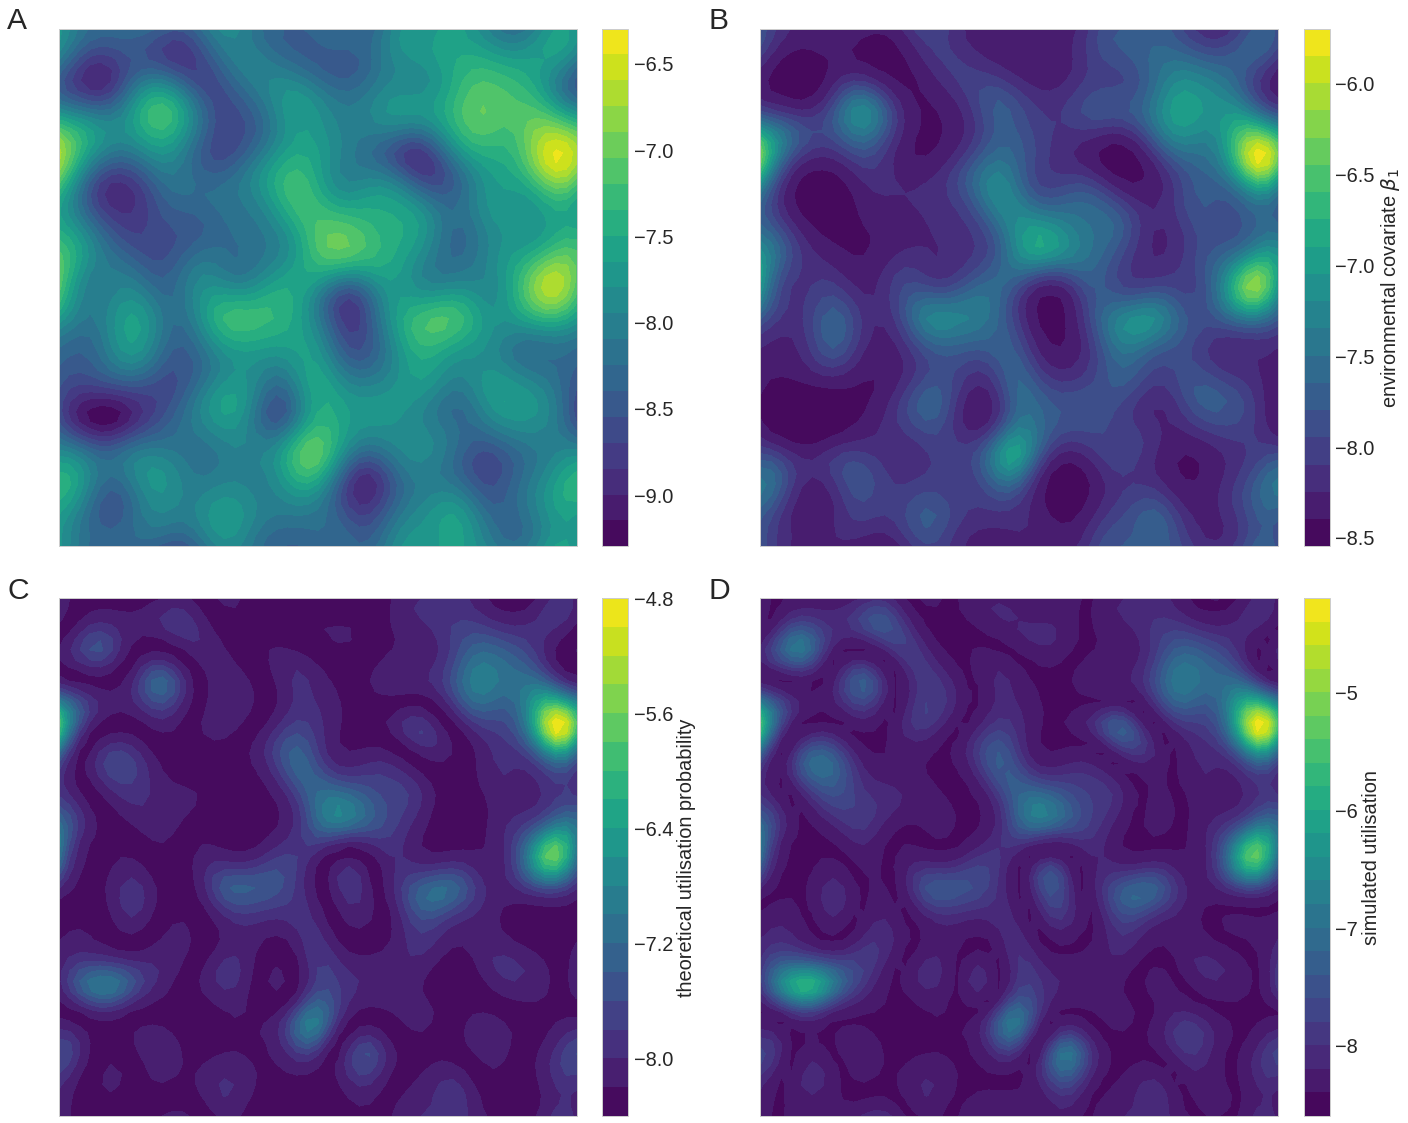

In [94]:
fig, axs = plt.subplots(2, 2, figsize=(24,20))

axs[0, 0].set_aspect('equal')





MN=np.exp(0.5*cov1 + (-0.8*cov2))
UD=np.divide(MN,np.sum(MN))


ec = np.sum(cov1*UD)
ec2 = np.sum(cov1**2*UD)


sigma=0.0

betas = 0.5+sigma*np.random.normal(size=(1000,1,1))

MNS = np.exp((betas*cov1))
MN=np.exp(0.5*cov1 + (-0.0*cov2))
UD=np.divide(MN,np.sum(MN))
UDS = MNS/np.sum(MNS,axis=(1,2)).reshape((-1,1,1))

UDUNC = np.mean(UDS,axis=0)


print(np.sum(UDUNC))
print(np.min(UDUNC))
print(np.max(UDUNC))
UDUNC = np.log(UDUNC)


ax00 = axs[0, 0].contourf(UDUNC,cmap='viridis',levels=20)#,vmin=0,vmax=3e-3)
#axs[0,0].set_title('A',loc='left',size=30,pad=100)
axs[0,0].text(-0.1,1,'A', size=30, transform=axs[0, 0].transAxes)
axs[0,0].tick_params( labelleft=False, labelbottom=False) 
cbar = fig.colorbar(ax00, ax=axs[0, 0],fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=20) 
cbar.formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.get_offset_text().set_fontsize(20)
cbar.ax.yaxis.set_offset_position('left')                         

tick_locator = tick.MaxNLocator(nbins=7)
cbar.locator = tick_locator
cbar.update_ticks()

axs[0, 1].set_aspect('equal')


sigma=0.5

betas = 0.5+sigma*np.random.normal(size=(1000,1,1))

MNS = np.exp((betas*cov1))
MN=np.exp(0.5*cov1 + (-0.0*cov2))
UD=np.divide(MN,np.sum(MN))
UDS = MNS/np.sum(MNS,axis=(1,2)).reshape((-1,1,1))

UDUNC = np.mean(UDS,axis=0)

print(np.sum(UDUNC))
print(np.min(UDUNC))
print(np.max(UDUNC))
UDUNC = np.log(UDUNC)

ax01 = axs[0, 1].contourf(UDUNC,cmap='viridis',levels=20)#,vmin=0,vmax=3e-3)

#axs[0,0].set_title('A',loc='left',size=30,pad=100)
axs[0,1].text(-0.1,1,'B', size=30, transform=axs[0, 1].transAxes)
axs[0,1].tick_params( labelleft=False, labelbottom=False) 
cbar = fig.colorbar(ax01, ax=axs[0, 1],fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=20) 
cbar.formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.get_offset_text().set_fontsize(20)
cbar.ax.yaxis.set_offset_position('left')                         

cbar.set_label(label=r'environmental covariate $\beta_1$',size=20)
tick_locator = tick.MaxNLocator(nbins=7)
cbar.locator = tick_locator
cbar.update_ticks()


axs[1, 0].set_aspect('equal')

sigma=1.0

betas = 0.5+sigma*np.random.normal(size=(1000,1,1))

MNS = np.exp((betas*cov1))
MN=np.exp(0.5*cov1 + (-0.0*cov2))
UD=np.divide(MN,np.sum(MN))
UDS = MNS/np.sum(MNS,axis=(1,2)).reshape((-1,1,1))

UDUNC = np.mean(UDS,axis=0)

print(np.sum(UDUNC))
print(np.min(UDUNC))
print(np.max(UDUNC))
UDUNC = np.log(UDUNC)

ax01 = axs[1, 0].contourf(UDUNC,cmap='viridis',levels=20)#,vmin=0,vmax=3e-3)

#axs[0,0].set_title('A',loc='left',size=30,pad=100)
axs[1,0].text(-0.1,1,'C', size=30, transform=axs[1, 0].transAxes)
axs[1,0].tick_params( labelleft=False, labelbottom=False) 
cbar = fig.colorbar(ax01, ax=axs[1, 0],fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=20) 
cbar.formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.get_offset_text().set_fontsize(20)
cbar.ax.yaxis.set_offset_position('left')                         
cbar.ax.tick_params(labelsize=20) 
cbar.set_label(label=r'theoretical utilisation probability',size=20)
tick_locator = tick.MaxNLocator(nbins=5)
cbar.locator = tick_locator
cbar.update_ticks()

# axs[1,0].plot(xy1[0:10000,0]%50,xy1[0:10000,1]%50,'.',color="black")
axs[1, 1].set_aspect('equal')

sigma=1.5

betas = 0.5+sigma*np.random.normal(size=(1000,1,1))

MNS = np.exp((betas*cov1))
MN=np.exp(0.5*cov1 + (-0.0*cov2))
UD=np.divide(MN,np.sum(MN))
UDS = MNS/np.sum(MNS,axis=(1,2)).reshape((-1,1,1))

UDUNC = np.mean(UDS,axis=0)

print(np.sum(UDUNC))
print(np.min(UDUNC))
print(np.max(UDUNC))
UDUNC = np.log(UDUNC)

ax11 = axs[1, 1].contourf(UDUNC,cmap='viridis',levels=20)#,vmin=0,vmax=3e-3)


axs[1,1].text(-0.1,1,'D', size=30, transform=axs[1, 1].transAxes)
axs[1,1].tick_params( labelleft=False, labelbottom=False) 
cbar = fig.colorbar(ax11, ax=axs[1, 1],fraction=0.046, pad=0.04)
cbar.formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.get_offset_text().set_fontsize(20)
cbar.ax.yaxis.set_offset_position('left')                         
cbar.ax.tick_params(labelsize=20) 
cbar.set_label(label=r'simulated utilisation',size=20)
tick_locator = tick.MaxNLocator(nbins=5)
cbar.locator = tick_locator
cbar.update_ticks()

plt.subplots_adjust(wspace=0.1, hspace=0.1)


# plt.savefig("covariates_and_distributions.png",bbox_inches='tight',dpi=300)
plt.show()

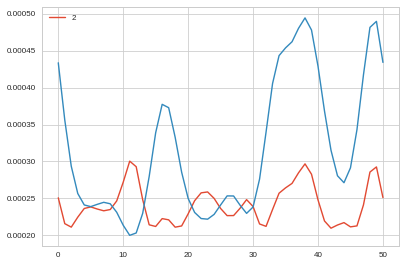

In [78]:
plt.plot(UDUNC[0],label='2')
sigma=0
betas = 0.5+sigma*np.random.normal(size=(1000,1,1))

MNS = np.exp((betas*cov1))
MN=np.exp(0.5*cov1 + (-0.0*cov2))
UD=np.divide(MN,np.sum(MN))
UDS = MNS/np.sum(MNS,axis=(1,2)).reshape((-1,1,1))

UDUNC = np.mean(UDS,axis=0)
plt.plot(UDUNC[0])
plt.legend()

In [81]:


sigma=0.0

betas = 0.5+sigma*np.random.normal(size=(1000,1,1))

MNS = np.exp((betas*cov1))
MN=np.exp(0.5*cov1 + (-0.0*cov2))
UD=np.divide(MN,np.sum(MN))
UDS = MNS/np.sum(MNS,axis=(1,2)).reshape((-1,1,1))

UDUNC = np.mean(UDS,axis=0)


print(np.sum(UDUNC))
print(UD[0,0])
print(UDUNC[0,0])


1.0
0.00043350232195254866
0.0004335023219525501


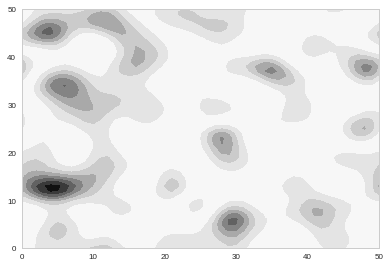

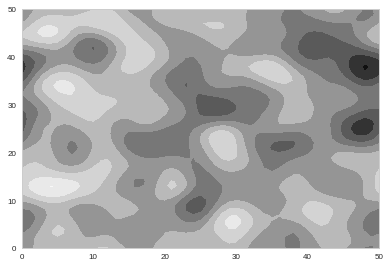

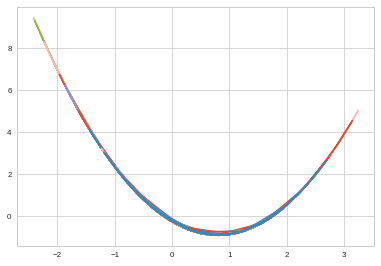

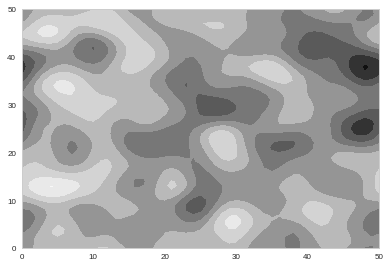

In [84]:
MN=np.exp(0.5*cov1 + (-0.8*cov2))
UD=np.divide(MN,np.sum(MN))

ec = np.sum(cov1*UD)
ec2 = np.sum(cov1**2*UD)

#UD.shape

plt.contourf((cov1-ec)**2 - (ec2-ec**2))
plt.show()
plt.contourf(cov1)
#(cov1-np.sum(cov1*UD))
ec2-ec**2

plt.show()
plt.plot(cov1,(cov1-ec)**2 - (ec2-ec**2))
plt.show()
plt.contourf(cov1)

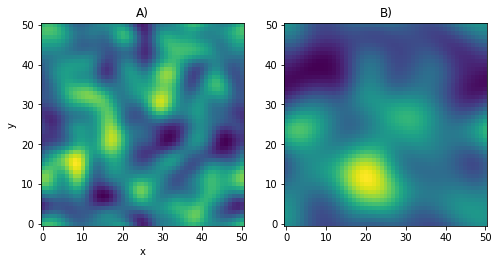

In [5]:
#Plotting covariates
fig, ax = plt.subplots(1,2,figsize=(8,6))
ax[0].imshow(cov1,origin='lower')
ax[0].set_title("A)")
ax[0].set_ylabel("y")
ax[0].set_xlabel("x")
ax[1].imshow(cov2,origin='lower')
ax[1].set_title("B)")
plt.savefig("New_finalcov.png")
plt.show()

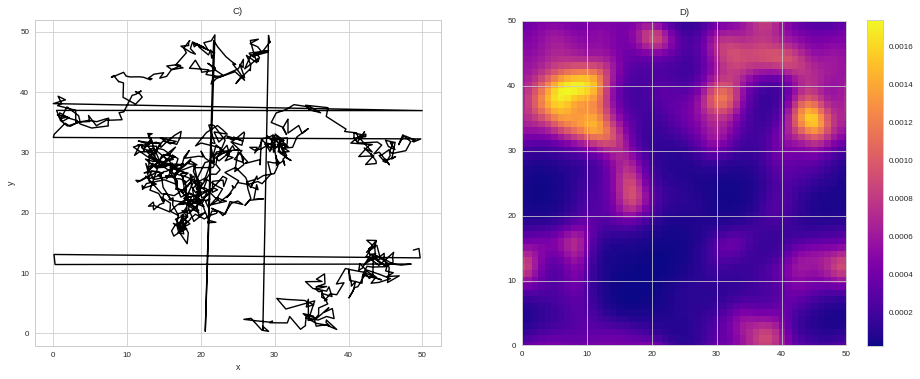

In [30]:
# Plotting both trajectory and utilisation distribution
fig, ax = plt.subplots(1,2,figsize=(16,6))
ax[0].plot(xy1[0:1000,0]%50,xy1[0:1000,1]%50,color="black")
ax[0].set_title("C)")
ax[0].set_ylabel("y")
ax[0].set_xlabel("x")
# ax[0].set_xlim([0,50])
# ax[0].set_ylim([0,50])

MN=np.exp(0.5*cov1 + (-0.8*cov2))
UD=np.divide(MN,np.sum(MN))
plt.imshow(UD,origin="lower",cmap="plasma")
plt.xlim([0,50])
plt.ylim([0,50])
plt.colorbar()
plt.title("D)")
plt.savefig("New_FinaltrajUD.png")
plt.show()

In [28]:
UD.shape

(51, 51)

In [41]:
ax[0].hist2d(xy1[0:1000,0]%50,xy1[0:1000,1]%50)

(array([[ 0.,  0.,  2.,  0.,  0.,  0.,  5., 26.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  4., 10.,  7.,  0.],
        [ 0.,  0.,  0.,  0., 19., 55., 49.,  4., 13.,  0.],
        [ 0.,  0.,  1., 39., 83., 92., 13.,  0., 10., 16.],
        [ 1.,  0.,  0., 10., 48., 39., 32.,  0., 14., 17.],
        [10.,  0.,  0.,  0., 14., 20., 38.,  1., 10., 28.],
        [13.,  5.,  0.,  0.,  0., 11., 43.,  8.,  0.,  0.],
        [23., 23.,  1.,  0.,  0.,  0.,  2.,  3.,  0.,  0.],
        [ 0., 22., 31.,  3.,  0., 13., 20.,  0.,  0.,  0.],
        [ 0.,  6., 14.,  0.,  0.,  8., 20.,  1.,  0.,  0.]]),
 array([ 0.04533365,  5.03670425, 10.02807485, 15.01944546, 20.01081606,
        25.00218666, 29.99355727, 34.98492787, 39.97629847, 44.96766908,
        49.95903968]),
 array([ 0.34646529,  5.25756852, 10.16867175, 15.07977498, 19.99087821,
        24.90198145, 29.81308468, 34.72418791, 39.63529114, 44.54639437,
        49.4574976 ]),
 <matplotlib.collections.QuadMesh at 0x7fa278e75610>)